In [2]:
import pandas as pd

In [3]:
train_df = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_train_featured.csv')
test_df = pd.read_csv('../results/outputs/Stress_level_dataset_featured/stress_level_test_featured.csv')

In [4]:
train_df_pca = pd.read_csv('../results/outputs/PCA/pca_train.csv')
test_df_pca = pd.read_csv('../results/outputs/PCA/pca_test.csv')

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 880 non-null    float64
 1   self_esteem                   880 non-null    float64
 2   mental_health_history         880 non-null    int64  
 3   depression                    880 non-null    float64
 4   headache                      880 non-null    float64
 5   blood_pressure                880 non-null    float64
 6   sleep_quality                 880 non-null    float64
 7   breathing_problem             880 non-null    float64
 8   noise_level                   880 non-null    float64
 9   living_conditions             880 non-null    float64
 10  safety                        880 non-null    float64
 11  basic_needs                   880 non-null    float64
 12  academic_performance          880 non-null    float64
 13  study

In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 220 non-null    float64
 1   self_esteem                   220 non-null    float64
 2   mental_health_history         220 non-null    int64  
 3   depression                    220 non-null    float64
 4   headache                      220 non-null    float64
 5   blood_pressure                220 non-null    float64
 6   sleep_quality                 220 non-null    float64
 7   breathing_problem             220 non-null    float64
 8   noise_level                   220 non-null    float64
 9   living_conditions             220 non-null    float64
 10  safety                        220 non-null    float64
 11  basic_needs                   220 non-null    float64
 12  academic_performance          220 non-null    float64
 13  study

In [7]:
feature_cols = [c for c in train_df.columns if c != "target"]

X_train = train_df[feature_cols]
y_train = train_df["target"]

x_test = test_df[feature_cols]
y_test = test_df["target"]

In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
svm = SVC(random_state=42)
svm.fit(X_train, y_train)

svm_preds = svm.predict(x_test)
svm_accuracy = accuracy_score(y_test, svm_preds)

print("SVM Accuracy:", svm_accuracy*100)
print(classification_report(y_test, svm_preds))

SVM Accuracy: 87.27272727272727
              precision    recall  f1-score   support

           0       0.86      0.82      0.84        74
           1       0.92      0.92      0.92        72
           2       0.84      0.88      0.86        74

    accuracy                           0.87       220
   macro avg       0.87      0.87      0.87       220
weighted avg       0.87      0.87      0.87       220



In [ ]:
#Doing same with PCA

In [14]:
train_df_pca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PC1     880 non-null    float64
 1   PC2     880 non-null    float64
 2   target  880 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 20.8 KB


In [15]:
feature_cols_pca = [c for c in train_df_pca.columns if c != "target"]

X_train_pca = train_df_pca[feature_cols_pca]
y_train_pca = train_df_pca["target"]

X_test_pca = test_df_pca[feature_cols_pca]
y_test_pca = test_df_pca["target"]

svm_pca = SVC(random_state=42)
svm_pca.fit(X_train_pca, y_train_pca)

svm_preds_pca = svm_pca.predict(X_test_pca)
svm_accuracy_pca = accuracy_score(y_test_pca, svm_preds_pca)

print("SVM Accuracy:", svm_accuracy_pca)
print(classification_report(y_test_pca, svm_preds_pca))

SVM Accuracy: 0.8954545454545455
              precision    recall  f1-score   support

           0       0.91      0.85      0.88        74
           1       1.00      0.89      0.94        72
           2       0.80      0.95      0.87        74

    accuracy                           0.90       220
   macro avg       0.91      0.90      0.90       220
weighted avg       0.91      0.90      0.90       220



In [ ]:
#hyperparameter tuning using gridsearchv

In [16]:
from sklearn.model_selection import GridSearchCV

In [17]:
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=svm_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_pca, y_train_pca)

print("Best SVM parameters:", grid_svm.best_params_)
print("Best SVM CV accuracy:", grid_svm.best_score_)

best_svm = grid_svm.best_estimator_
tuned_svm_preds = best_svm.predict(X_test_pca)
tuned_svm_accuracy = accuracy_score(y_test_pca, tuned_svm_preds)

print("Tuned SVM Test Accuracy:", tuned_svm_accuracy)
print(classification_report(y_test_pca, tuned_svm_preds))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best SVM parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Best SVM CV accuracy: 0.8840909090909091
Tuned SVM Test Accuracy: 0.8954545454545455
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        74
           1       0.98      0.89      0.93        72
           2       0.83      0.91      0.86        74

    accuracy                           0.90       220
   macro avg       0.90      0.90      0.90       220
weighted avg       0.90      0.90      0.90       220



In [ ]:
#so hyper parameter tuning is not nessory and use PCA as dataset

In [18]:
import joblib

joblib.dump(svm_pca, "../results/model_trained_files/svm_model.pkl")

['../results/model_trained_files/svm_model.pkl']

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

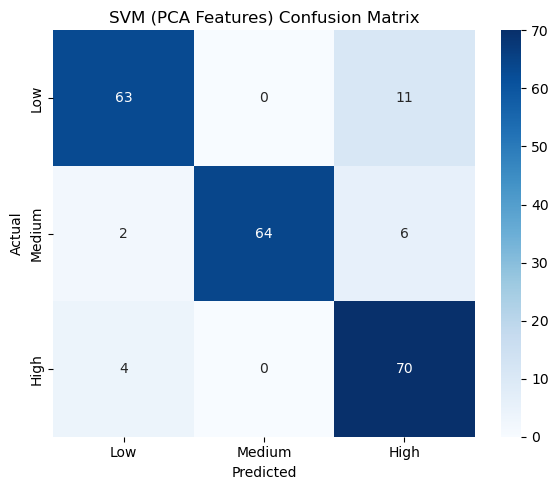

In [22]:
cm_pca = confusion_matrix(y_test_pca, svm_preds_pca)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM (PCA Features) Confusion Matrix")
plt.tight_layout()
plt.savefig("svm_pca_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

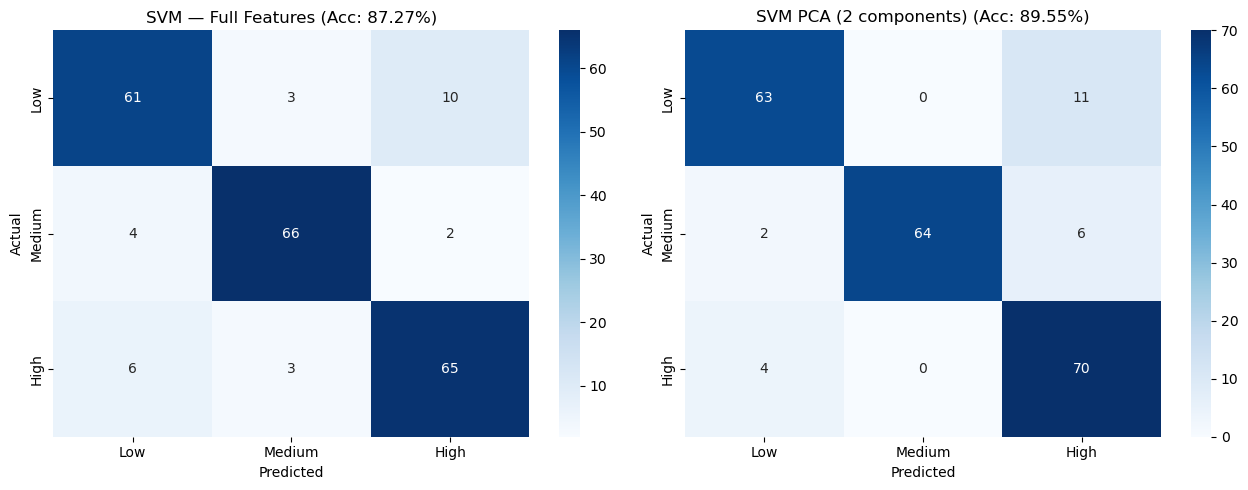

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_full = confusion_matrix(y_test, svm_preds)
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
axes[0].set_title(f"SVM — Full Features (Acc: {svm_accuracy:.2%})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
axes[1].set_title(f"SVM PCA (2 components) (Acc: {svm_accuracy_pca:.2%})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("svm_confusion_comparison_full_vs_pca.png", dpi=150, bbox_inches='tight')
plt.show()